In [67]:
import torch
from torchvision.datasets import FashionMNIST
from torchvision import transforms, models
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from torcheval.metrics import PeakSignalNoiseRatio

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [69]:
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [70]:
def pgd(model, x, y, epsilon, alpha, num_iter):
    # Construct PGD adversarial examples on the examples X
    # inputs:
    #     net: the network through which we pass the inputs
    #     x: the original example which we aim to perturb to make an adversarial example
    #     y: the true label of x
    #     alpha: step size
    #     epsilon: perturbation budget
    #     iter: number of iterations in the PGD algorithm
    # test
    # outputs:
    #     x_adv : the adversarial example constructed from x
    delta = torch.zeros_like(x, requires_grad=True)
    for t in range(num_iter):
        loss = nn.CrossEntropyLoss()(model(x + delta), y)
        loss.backward()
        delta.data = (delta + x.shape[0] * alpha * delta.grad.data).clamp(-epsilon, epsilon)
        delta.grad.zero_()

    return torch.clip(delta.detach() + x, 0, 1)

def fgsm(model, x, y, epsilon):
    # Construct FGSM adversarial examples on the examples X
    #     inputs:
    #         net: the network through which we pass the inputs
    #         x: the original example which we aim to perturb to make an adversarial example
    #         y: the true label of x
    #         eps: perturbation budget
    #     outputs:
    #         x_adv : the adversarial example constructed from x

    eta = torch.zeros_like(x, requires_grad=True)
    loss = nn.CrossEntropyLoss()(model(x + eta), y)
    loss.backward()
    return torch.clip(epsilon * eta.grad.detach().sign() + x, 0, 1)

metric = PeakSignalNoiseRatio()

In [71]:
eps = 8.0/255
alpha = 5.0
its = 7

model = models.resnet50()
# modify the input and output layers
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.fc = nn.Linear(2048, 10)
model.load_state_dict(torch.load('model/ResNet50_FashionMNIST.pth'))
model = model.to(device)

In [72]:
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

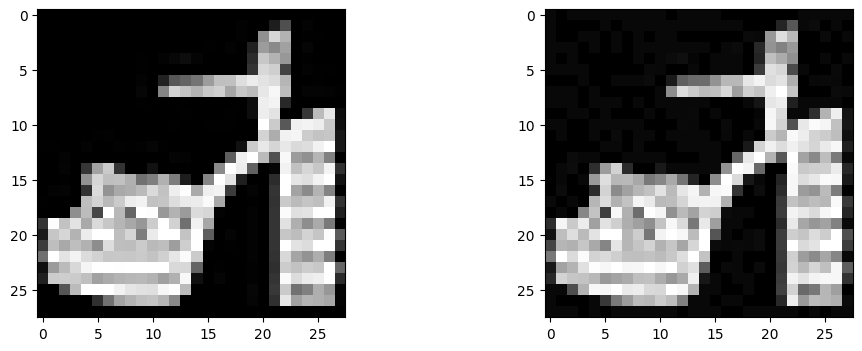

In [79]:
test = fgsm(model, x, y, eps)
# test = pgd(model, x, y, eps, alpha, its)
test = test.cpu()
x = x.cpu()
#show images
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(x[5].reshape(28,28), cmap='gray')
ax[1].imshow(test[5].reshape(28,28), cmap='gray')
plt.show()

In [82]:
metric.reset()
metric.update(test[5], x[5])
metric.compute()

tensor(31.4585)

In [75]:
#fgsm attack
atk_img = []
atk_label = []
model.eval()
val_correct = 0
# val_bar = tqdm(train_loader, position=0, leave=True)
val_bar = tqdm(test_loader, position=0, leave=True)
for x, y in val_bar:
    x, y = x.to(device), y.to(device)
    # atk_x = fgsm(model, x, y, eps)
    atk_x = pgd(model, x, y, eps, alpha, its)
    with torch.no_grad():
        y_pred = model(atk_x)
        atk_x = atk_x.reshape(-1, 28, 28)
        atk_img += atk_x
        atk_label += y
        class_pred = y_pred.argmax(dim=1)
        val_correct += class_pred.eq(y).sum().item()
# val_accuracy = val_correct / len(train_dataset)
val_accuracy = val_correct / len(test_dataset)

print(f" attack accuracy: {val_accuracy:.4f}")

100%|██████████| 20/20 [00:16<00:00,  1.24it/s]

 attack accuracy: 0.5305


resnet_pgd_fashion_train 0.5672

resnet_fgsm_fashion_train 0.5606

resnet_fgsm_fashion_test 0.5445

resnet_pgd_fashion_test 0.5305

In [76]:
from torch.utils.data import Dataset
class AdvDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)

In [77]:
adv_dataset = AdvDataset(atk_img, atk_label)

In [78]:
torch.save(adv_dataset, './adv_data/resnet_pgd_fashion_test')